In [1]:
# https://github.com/FJROAR/Ejemplo-Blog-Bayesian-Net/blob/master/ejemplo%20blog%20post14.py
# https://fjroar.wixsite.com/cosasveredes/post/aplicando-redes-bayesianas-aplicaciones-a-cr%C3%A9dito-hipotecario
# https://pybbn.rocketvector.io/

!pip install pybbn
import pandas as pd # for data manipulation
import networkx as nx # for drawing graphs
import matplotlib.pyplot as plt # for drawing graphs

# for creating Bayesian Belief Networks (BBN)
from pybbn.graph.dag import Bbn
from pybbn.graph.edge import Edge, EdgeType
from pybbn.graph.jointree import EvidenceBuilder
from pybbn.graph.node import BbnNode
from pybbn.graph.variable import Variable
from pybbn.pptc.inferencecontroller import InferenceController



  Preparing metadata (setup.py) ... done
  Created wheel for pybbn: filename=pybbn-3.2.3-py3-none-any.whl size=40373 sha256=6c6e1a1d9e9d2c270851f5203eddef1ac2991c12962518e271712ee36ba28cf0
  Stored in directory: /Users/abc/Library/Caches/pip/wheels/97/20/85/52b65994184561eecc73318b47effb93e250a3dc3264db32c9
Successfully built pybbn


In [ ]:
# Se introducen manualmente las tablas de probabilidad y condicionadas

# Nodo "edad"
# - Variable binaria con estados: S (sí), N (no)
# - Distribución marginal: P(edad=S)=0.6, P(edad=N)=0.4
edad = BbnNode(Variable(0, 'edad', ['S', 'N']), [0.6, 0.4])

# Nodo "economia"
# - P(economia=S)=0.6, P(economia=N)=0.4
economia = BbnNode(Variable(1, 'economia', ['S', 'N']), [0.6, 0.4])

# Nodo "ahorro"
# - Variable con dependencia de padres (probabilidades condicionadas)
# - El vector se interpreta como pares [P(S), P(N)] para cada combinación de padres
ahorro = BbnNode(Variable(2, 'ahorro', ['S', 'N']), [
    0.8, 0.2,   # caso 1
    0.4, 0.6,   # caso 2
    0.5, 0.5,   # caso 3
    0.3, 0.7    # caso 4
])

# Nodo "trabajo"
trabajo = BbnNode(Variable(3, 'trabajo', ['S', 'N']), [
    0.3, 0.7,   # caso 1
    0.1, 0.9,   # caso 2
    0.8, 0.2,   # caso 3
    0.4, 0.6    # caso 4
])

# Nodo "vivienda"
vivienda = BbnNode(Variable(4, 'vivienda', ['S', 'N']), [
    0.7, 0.3,   # caso 1
    0.4, 0.6    # caso 2
])

# Nodo "dificultad"
dificultad = BbnNode(Variable(5, 'dificultad', ['S', 'N']), [
    0.01, 0.99, # caso 1
    0.05, 0.95, # caso 2
    0.4, 0.6,   # caso 3
    0.8, 0.2    # caso 4
])

# Nodo "paga"
paga = BbnNode(Variable(6, 'paga', ['S', 'N']), [
    0.6, 0.4,   # caso 1
    0.98, 0.02, # caso 2
    0.1, 0.9,   # caso 3
    0.95, 0.05  # caso 4
])


In [ ]:
# Se crea la estructura de interrelaciones o grafo bayesiano
bbn = Bbn() \
    .add_node(edad) \
    .add_node(economia) \
    .add_node(ahorro) \
    .add_node(trabajo) \
    .add_node(vivienda) \
    .add_node(dificultad) \
    .add_node(paga) \
    .add_edge(Edge(trabajo, ahorro, EdgeType.DIRECTED)) \
    .add_edge(Edge(edad, ahorro, EdgeType.DIRECTED)) \
    .add_edge(Edge(edad, trabajo, EdgeType.DIRECTED)) \
    .add_edge(Edge(economia, trabajo, EdgeType.DIRECTED)) \
    .add_edge(Edge(economia, vivienda, EdgeType.DIRECTED)) \
    .add_edge(Edge(ahorro, dificultad, EdgeType.DIRECTED)) \
    .add_edge(Edge(trabajo, dificultad, EdgeType.DIRECTED)) \
    .add_edge(Edge(vivienda, paga, EdgeType.DIRECTED)) \
    .add_edge(Edge(dificultad, paga, EdgeType.DIRECTED))
    # dificultad ← paga depende de dificultad

# Convert the BBN to a join tree
join_tree = InferenceController.apply(bbn)


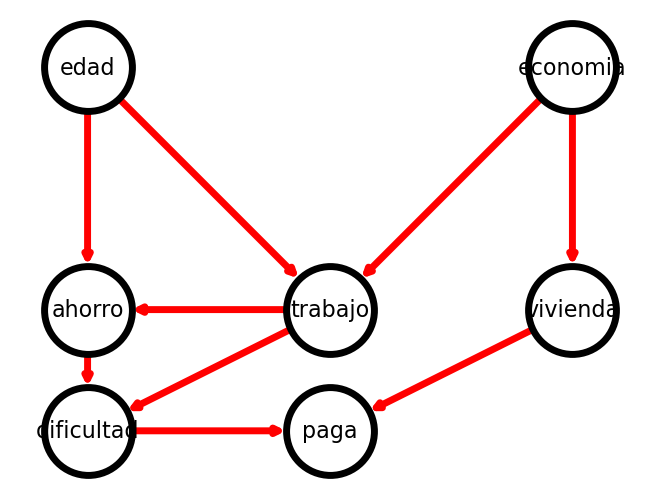

In [4]:
# Set node positions
pos = {0: (-1, 2), 1: (1, 2), 2: (-1, 0),
       3: (0, 0), 4: (1, 0), 5: (-1, -1), 6: (0, -1)}

# Set options for graph looks
options = {
    "font_size": 16,
    "node_size": 4000,
    "node_color": "white",
    "edgecolors": "black",
    "edge_color": "red",
    "linewidths": 5,
    "width": 5,}

# Generate graph
n, d = bbn.to_nx_graph()
nx.draw(n, with_labels=True, labels=d, pos=pos, **options)

# Update margins and print the graph
ax = plt.gca()
ax.margins(0.10)
plt.axis("off")
plt.show()



📌 Relaciones en tu grafo

edad → ahorro y trabajo → ahorro

El ahorro depende de la edad y de si la persona trabaja.

edad → trabajo y economia → trabajo

El trabajo depende de la edad y de la situación económica.

economia → vivienda

La vivienda depende del estado económico.

ahorro → dificultad y trabajo → dificultad

La dificultad (probablemente para pagar) depende de si la persona ahorra y de si trabaja.

vivienda → paga y dificultad → paga

La probabilidad de pagar depende de si la persona tiene vivienda y de si enfrenta dificultades.

🔮 Interpretación

El grafo modela una cadena de causas y efectos en términos económicos:

La edad y la economía influyen en el trabajo.

A partir del trabajo, se ve si hay ahorro y si existen dificultades.

Junto con la vivienda, eso impacta directamente en la probabilidad de pagar.

In [ ]:
# Probabilidades marginales

# Definimos una función auxiliar para imprimir las probabilidades de cada nodo
def print_probs():
    # Recorremos todos los nodos del join tree (árbol de unión)
    for node in join_tree.get_bbn_nodes():
        # Obtenemos el potencial asociado al nodo
        # (es la distribución de probabilidad marginal de ese nodo)
        potential = join_tree.get_bbn_potential(node)
        
        # Imprimimos el nombre del nodo
        print("Node:", node)
        
        # Imprimimos los valores de probabilidad para cada estado del nodo
        print("Values:")
        print(potential)
        
        print('----------------')

# Se aplica la función -> muestra las probabilidades marginales de todos los nodos
print_probs()


Node: 4|vivienda|S,N
Values:
4=S|0.58000
4=N|0.42000
----------------
Node: 5|dificultad|S,N
Values:
5=S|0.35578
5=N|0.64422
----------------
Node: 6|paga|S,N
Values:
6=S|0.75881
6=N|0.24119
----------------
Node: 1|economia|S,N
Values:
1=S|0.60000
1=N|0.40000
----------------
Node: 2|ahorro|S,N
Values:
2=S|0.48520
2=N|0.51480
----------------
Node: 3|trabajo|S,N
Values:
3=S|0.38800
3=N|0.61200
----------------
Node: 0|edad|S,N
Values:
0=S|0.60000
0=N|0.40000
----------------


In [ ]:
# Introducción de evidencias

# Función auxiliar para añadir evidencia (observaciones) en el join tree
def evidence(ev, nod, cat, val):
    ev = EvidenceBuilder() \
        .with_node(join_tree.get_bbn_node_by_name(nod)) \
        .with_evidence(cat, val) \
        .build()
    # Aplicamos la observación al join tree
    join_tree.set_observation(ev)


# Uso de la función para añadir evidencias
evidence('ev1', 'economia', 'S', 1)   # economía = S (buen año económico, certeza 100%)
evidence('ev2', 'edad', 'N', 1)       # edad = N (joven, certeza 100%)
evidence('ev3', 'trabajo', 'S', 1)    # trabajo = S (tiene empleo, certeza 100%)
evidence('ev4', 'vivienda', 'S', 1)   # vivienda = S (buen momento en vivienda, certeza 100%)

# Recalculamos y mostramos las probabilidades marginales
print_probs()


Node: 4|vivienda|S,N
Values:
4=S|1.00000
4=N|0.00000
----------------
Node: 5|dificultad|S,N
Values:
5=S|0.24400
5=N|0.75600
----------------
Node: 6|paga|S,N
Values:
6=S|0.88728
6=N|0.11272
----------------
Node: 1|economia|S,N
Values:
1=S|1.00000
1=N|0.00000
----------------
Node: 2|ahorro|S,N
Values:
2=S|0.40000
2=N|0.60000
----------------
Node: 3|trabajo|S,N
Values:
3=S|1.00000
3=N|0.00000
----------------
Node: 0|edad|S,N
Values:
0=S|0.00000
0=N|1.00000
----------------


In [7]:
# nueva evidencia

evidence('ev1', 'paga', 'N', 1)   # no pagó
evidence('ev2', 'edad', 'S', 1)   # edad elevada
evidence('ev3', 'ahorro', 'S', 1) # tiene ahorros

print_probs()


Node: 4|vivienda|S,N
Values:
4=S|1.00000
4=N|0.00000
----------------
Node: 5|dificultad|S,N
Values:
5=S|0.16807
5=N|0.83193
----------------
Node: 6|paga|S,N
Values:
6=S|0.00000
6=N|1.00000
----------------
Node: 1|economia|S,N
Values:
1=S|1.00000
1=N|0.00000
----------------
Node: 2|ahorro|S,N
Values:
2=S|1.00000
2=N|0.00000
----------------
Node: 3|trabajo|S,N
Values:
3=S|1.00000
3=N|0.00000
----------------
Node: 0|edad|S,N
Values:
0=S|1.00000
0=N|0.00000
----------------
